In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import joblib

In [6]:
df = pd.read_csv("/Users/deekshadhatterwal/Downloads/internship_placement_super_9999.csv")  


In [43]:
df.fillna(df.mean(numeric_only=True), inplace=True)
print("Missing Values:\n", df.isnull().sum())


Missing Values:
 CGPA                          0
Major Projects                0
Workshops/Certificatios       0
Mini Projects                 0
Skills                        0
Communication Skill Rating    0
Internship                    0
Hackathon                     0
12th Percentage               0
10th Percentage               0
backlogs                      0
Branch                        0
PlacementStatus               0
Salary                        0
dtype: int64


In [8]:
df.head()

,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,Branch,PlacementStatus,Salary
0,7.02,3,2,0,6,5.00,1,1,95.56,98.94,5,CSE,1,1767106.0
1,9.58,0,3,2,9,6.98,1,3,92.72,66.78,3,CSE,1,2000000.0
2,8.59,1,1,2,9,3.25,0,2,95.93,92.79,0,Mechanical,1,1682809.0
3,6.27,0,5,5,9,3.82,1,1,94.86,95.30,0,Mechanical,1,1535003.0
4,8.04,1,5,2,2,9.85,2,0,94.21,98.87,5,Electrical,0,0.0


In [10]:
df.tail()

,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,Branch,PlacementStatus,Salary
9994,6.63,0,0,0,3,5.51,1,0,84.86,80.79,1,Mechanical,0,0.0
9995,7.43,3,1,3,4,5.97,2,1,60.04,96.50,3,ECE,0,0.0
9996,8.00,0,5,3,10,3.24,2,2,82.96,75.55,3,Electrical,1,1550195.0
9997,6.70,0,1,3,3,3.07,1,2,82.86,78.56,2,Electrical,0,0.0
9998,5.98,2,5,2,4,5.67,2,2,92.32,84.36,3,IT,0,0.0


In [12]:
df.shape


(9999, 14)

In [51]:
df.columns

Index(['CGPA', 'Major Projects', 'Workshops/Certificatios', 'Mini Projects',
       'Skills', 'Communication Skill Rating', 'Internship', 'Hackathon',
       '12th Percentage', '10th Percentage', 'backlogs', 'Branch',
       'PlacementStatus', 'Salary'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CGPA                        9999 non-null   float64
 1   Major Projects              9999 non-null   int64  
 2   Workshops/Certificatios     9999 non-null   int64  
 3   Mini Projects               9999 non-null   int64  
 4   Skills                      9999 non-null   int64  
 5   Communication Skill Rating  9999 non-null   float64
 6   Internship                  9999 non-null   int64  
 7   Hackathon                   9999 non-null   int64  
 8   12th Percentage             9999 non-null   float64
 9   10th Percentage             9999 non-null   float64
 10  backlogs                    9999 non-null   int64  
 11  Branch                      9999 non-null   object 
 12  PlacementStatus             9999 non-null   int64  
 13  Salary                      9999 

In [55]:
df.describe()

,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus,Salary
count,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.00000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9.999000e+03
mean,7.725285,1.502550,2.499850,2.493649,5.961996,6.238713,1.00340,1.499250,79.076985,79.676179,2.518852,0.450045,7.986135e+05
std,1.290951,1.112841,1.694801,1.709713,2.588609,2.164991,0.81604,1.120636,10.991438,11.236325,1.719480,0.497523,8.893369e+05
min,5.500000,0.000000,0.000000,0.000000,2.000000,2.500000,0.00000,0.000000,60.000000,60.000000,0.000000,0.000000,0.000000e+00
25%,6.600000,1.000000,1.000000,1.000000,4.000000,4.380000,0.00000,0.000000,69.560000,69.915000,1.000000,0.000000,0.000000e+00
50%,7.710000,2.000000,3.000000,2.000000,6.000000,6.200000,1.00000,1.000000,79.240000,79.710000,3.000000,0.000000,0.000000e+00
75%,8.850000,2.000000,4.000000,4.000000,8.000000,8.100000,2.00000,3.000000,88.580000,89.465000,4.000000,1.000000,1.749162e+06
max,10.000000,3.000000,5.000000,5.000000,10.000000,10.000000,2.00000,3.000000,98.000000,98.990000,5.000000,1.000000,2.000000e+06


In [57]:
df.nunique()

CGPA                           451
Major Projects                   4
Workshops/Certificatios          6
Mini Projects                    6
Skills                           9
Communication Skill Rating     751
Internship                       3
Hackathon                        4
12th Percentage               3552
10th Percentage               3615
backlogs                         6
Branch                           5
PlacementStatus                  2
Salary                        3914
dtype: int64

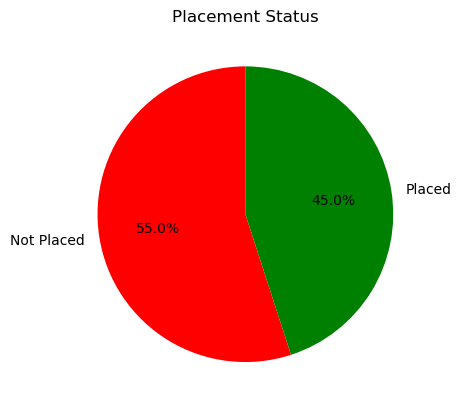

In [59]:
labels = ['Not Placed', 'Placed']
sizes = df['PlacementStatus'].value_counts()

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['red', 'green'])
plt.title("Placement Status")
plt.show()


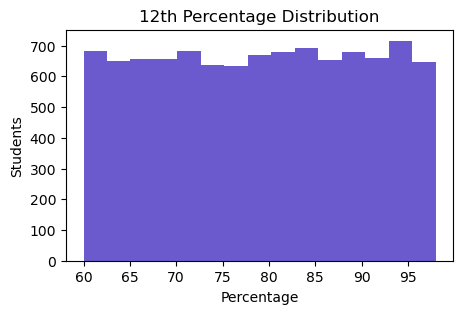

In [61]:

plt.figure(figsize=(5,3))
plt.hist(df['12th Percentage'], bins=15, color='slateblue')
plt.title("12th Percentage Distribution")
plt.xlabel("Percentage")
plt.ylabel("Students")
plt.show()


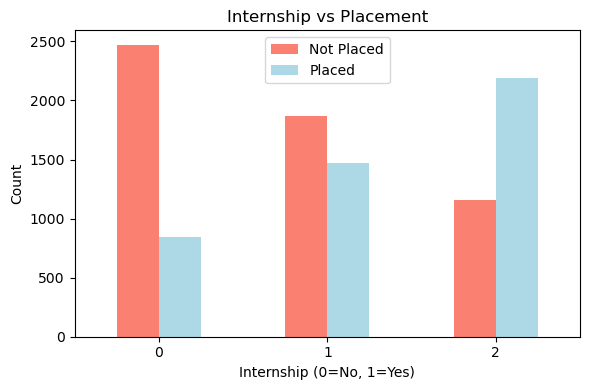

In [63]:
internship_counts = df.groupby(['Internship', 'PlacementStatus']).size().unstack()
internship_counts.plot(kind='bar', figsize=(6, 4), color=['salmon', 'lightblue'])
plt.title("Internship vs Placement")
plt.xlabel("Internship (0=No, 1=Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(["Not Placed", "Placed"])
plt.tight_layout()
plt.show()

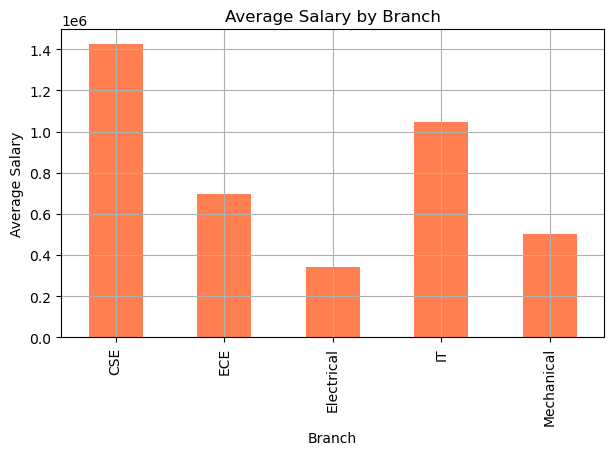

In [65]:
le = LabelEncoder()
df['Branch'] = le.fit_transform(df['Branch'])               
df['Branch_Name'] = le.inverse_transform(df['Branch']) 


branch_avg_salary = df.groupby('Branch_Name')['Salary'].mean()
plt.figure(figsize=(7, 4))
branch_avg_salary.plot(kind='bar', color='coral')
plt.title("Average Salary by Branch")
plt.xlabel("Branch")
plt.ylabel("Average Salary")
plt.grid(True)
plt.show()

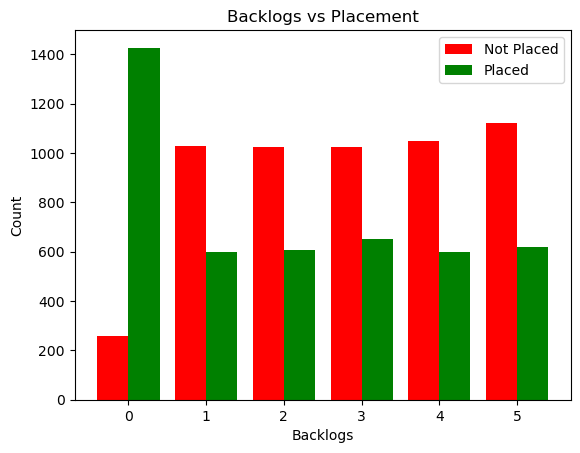

In [67]:
data = df.groupby(['backlogs', 'PlacementStatus']).size().unstack(fill_value=0)

x = range(len(data))
plt.bar([i - 0.2 for i in x], data[0], width=0.4, label='Not Placed', color='red')
plt.bar([i + 0.2 for i in x], data[1], width=0.4, label='Placed', color='green')

plt.title("Backlogs vs Placement")
plt.xlabel("Backlogs")
plt.ylabel("Count")
plt.xticks(ticks=x, labels=data.index)
plt.legend()
plt.show()


In [69]:
# Drop columns that are not needed for ML modeling
df.drop(['CGPA Range', 'CommSkillRange', 'CGPA_Rounded', 'Branch_Name'], axis=1, inplace=True, errors='ignore')

# Keep only numeric columns for modeling
df = df.select_dtypes(include=['number'])


Random Forest: 0.90
SVM: 0.78


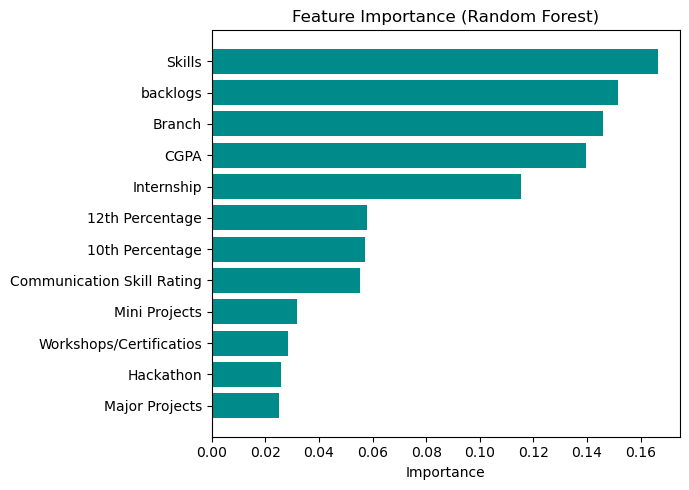

In [71]:


X = df.drop(['PlacementStatus', 'Salary'], axis=1, errors='ignore')
y = df['PlacementStatus']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf = RandomForestClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)


rf.fit(X_train, y_train)
svm.fit(X_train, y_train)


print(f"Random Forest: {accuracy_score(y_test, rf.predict(X_test)):.2f}")
print(f"SVM: {accuracy_score(y_test, svm.predict(X_test)):.2f}")

# Feature Importance (Random Forest)
importances = rf.feature_importances_
feature_names = X.columns
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='darkcyan')
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [73]:
joblib.dump(rf, "rf_model_clean_10k.joblib")
print("Classification model saved as rf_model_clean_10k.joblib")

Classification model saved as rf_model_clean_10k.joblib


In [75]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Sirf placed students ke liye salary regression
df = df[df['PlacementStatus'] == 1].copy()
le = LabelEncoder()
df['Branch'] = le.fit_transform(df['Branch'])

X = df.drop(['PlacementStatus', 'Salary'], axis=1)
y = df['Salary']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest Regression Results:")
print("MSE:", mse)
print("RMSE:", mse ** 0.5)
print("R² Score:", r2)




Random Forest Regression Results:
MSE: 720472818.5721505
RMSE: 26841.62473793549
R² Score: 0.9736823555095193


In [79]:
joblib.dump(reg, "salary_model_10k.joblib")
print("Regression model saved as salary_model_10k.joblib")

Regression model saved as salary_model_10k.joblib
